# Hluti 1

## Prufukeyrsla

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import diags, csr_matrix
import Foll

In [2]:
L = 1
T = 1/20
N = 6
M = 4

def f(x):
    return np.ones_like(x) * 100

def psi(t):
    return np.zeros_like(t)

def phi(t):
    return np.zeros_like(t)

In [3]:
print(Foll.heatwave(L, T, N, M, psi, phi, f))

Sigma: 0.45000000000000007
[[100.     100.     100.     100.     100.     100.     100.    ]
 [  0.     100.     100.     100.     100.     100.       0.    ]
 [  0.      55.     100.     100.     100.      55.       0.    ]
 [  0.      50.5     79.75   100.      79.75    50.5      0.    ]
 [  0.      40.9375  75.7     81.775   75.7     40.9375   0.    ]]


## Bein Lausn

In [4]:
def f_0(x):
    return 1 - np.abs(x- 1)

L_0 = 2
T_0 = 1
N_0 = 10
M_0 = 100

hw = Foll.heatwave(L_0,T_0,N_0,M_0,psi,phi,f_0)

Sigma: 0.24999999999999994


In [5]:
print("HW:", hw[-1,:])
print(hw.shape)

HW: [0.         0.02119985 0.04032452 0.05550194 0.06524644 0.06860417
 0.06524644 0.05550194 0.04032452 0.02119985 0.        ]
(101, 11)


In [6]:
sol = []
for j in range(M_0+1):
    for i in range(N_0+1):    
        sol.append(Foll.ua_theoretical(L_0/(N_0)*i,T_0/(M_0)*j ,2))

ua = np.array(sol).reshape(M_0+1,N_0+1)

In [7]:
print("UA:", ua[-1,:])

UA: [0.00000000e+00 2.12419275e-02 4.04045472e-02 5.56120883e-02
 6.53759307e-02 6.87403215e-02 6.53759307e-02 5.56120883e-02
 4.04045472e-02 2.12419275e-02 8.41826146e-18]


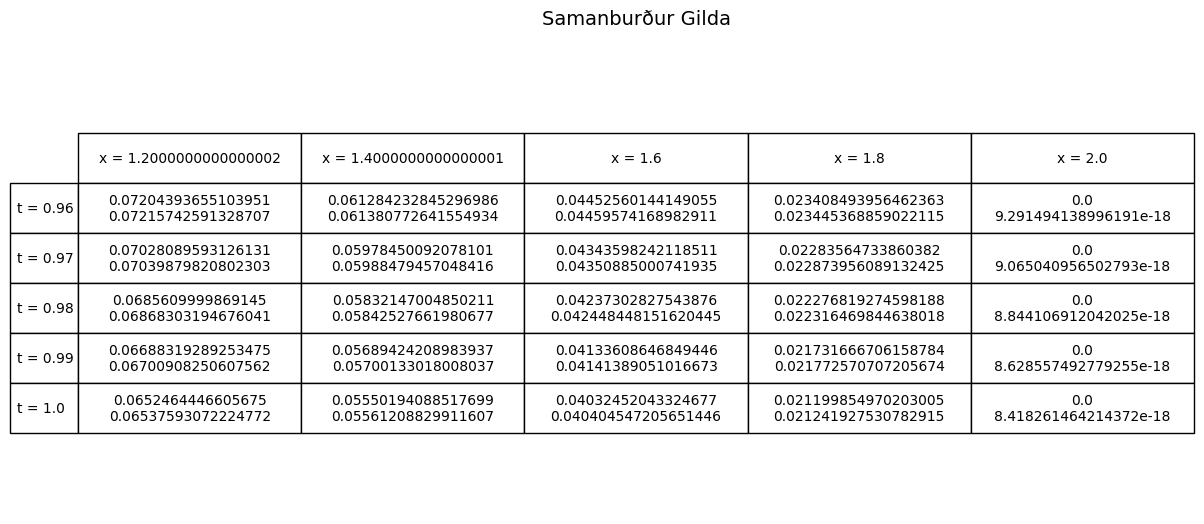

In [8]:
x_vals = [f"x = {v}" for v in np.linspace(0, L_0, N_0+1)[-5:]]
t_vals = [f"t = {v}" for v in np.linspace(0, T_0, M_0+1)[-5:]]


Foll.plot_comparison_table(hw[-5:,-5:], ua[-5:,-5:], x_vals, t_vals, title="Samanburður Gilda")

## Orka

### Orka sem fall af tíma

In [9]:
t = np.linspace(0,1,101)

E_comp = Foll.E_computed(hw, 1/5)
print(E_comp[:5])

[0.34       0.321      0.304375   0.28902344 0.27466309]


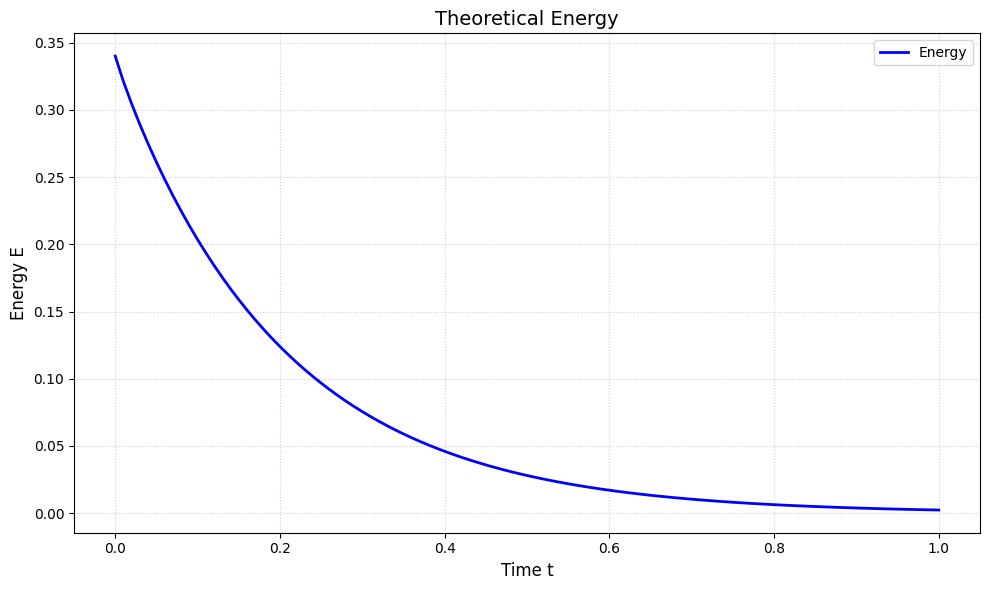

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(t, E_comp, label='Energy', color='blue', linewidth=2)

plt.title('Theoretical Energy', fontsize=14)
plt.xlabel('Time t', fontsize=12)
plt.ylabel('Energy E', fontsize=12)

# Grid: 'alpha' controls transparency, 'linestyle' makes it less distracting
plt.grid(True, linestyle=':', alpha=0.6)

# Legend: automatically uses the 'label' arguments from plt.plot()
plt.legend(loc='best', frameon=True)

# 4. Show/Save
plt.tight_layout() # Adjusts spacing so labels don't get cut off
plt.savefig('E_theoretical.png')
plt.show()

In [11]:
E_theor = []
for i in range(101):
    E_theor.append(Foll.E_theoretical(1/101 * i,2))

print(E_theor[:5])

[np.float64(0.3333333264896874), np.float64(0.31562752425476764), np.float64(0.299658240189667), np.float64(0.28481941737785604), np.float64(0.2708947811246647)]


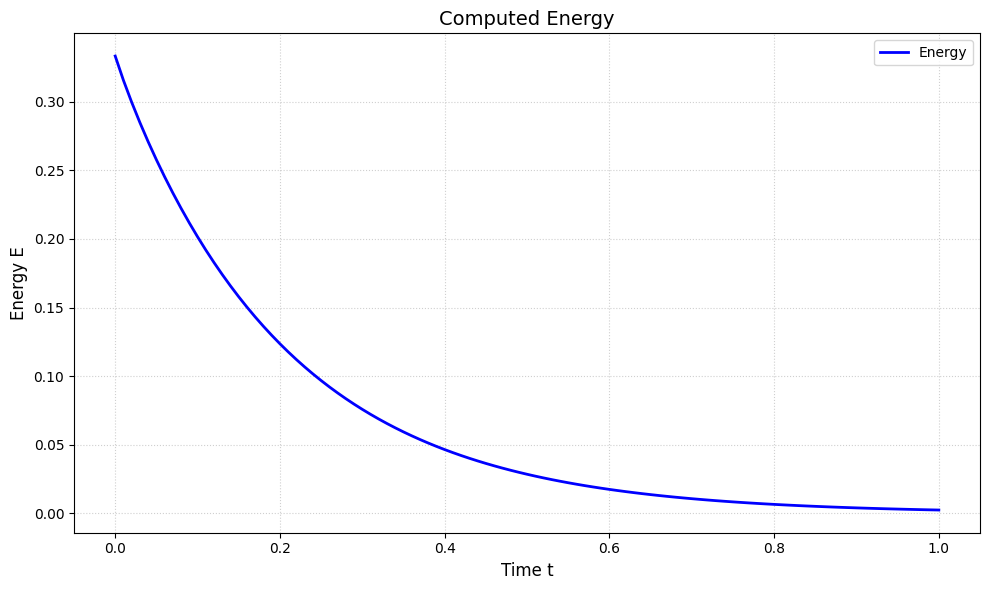

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(t, E_theor, label='Energy', color='blue', linewidth=2)

plt.title('Computed Energy', fontsize=14)
plt.xlabel('Time t', fontsize=12)
plt.ylabel('Energy E', fontsize=12)

# Grid: 'alpha' controls transparency, 'linestyle' makes it less distracting
plt.grid(True, linestyle=':', alpha=0.6)

# Legend: automatically uses the 'label' arguments from plt.plot()
plt.legend(loc='best', frameon=True)

# 4. Show/Save
plt.tight_layout() # Adjusts spacing so labels don't get cut off
plt.savefig('E_Computed.png')
plt.show()

### Breyting á Orku m.t.t tíma

In [13]:
t2 = np.linspace(1/100,1,100)

dE_theor = Foll.dE_theoretical(E_theor, 1/100)

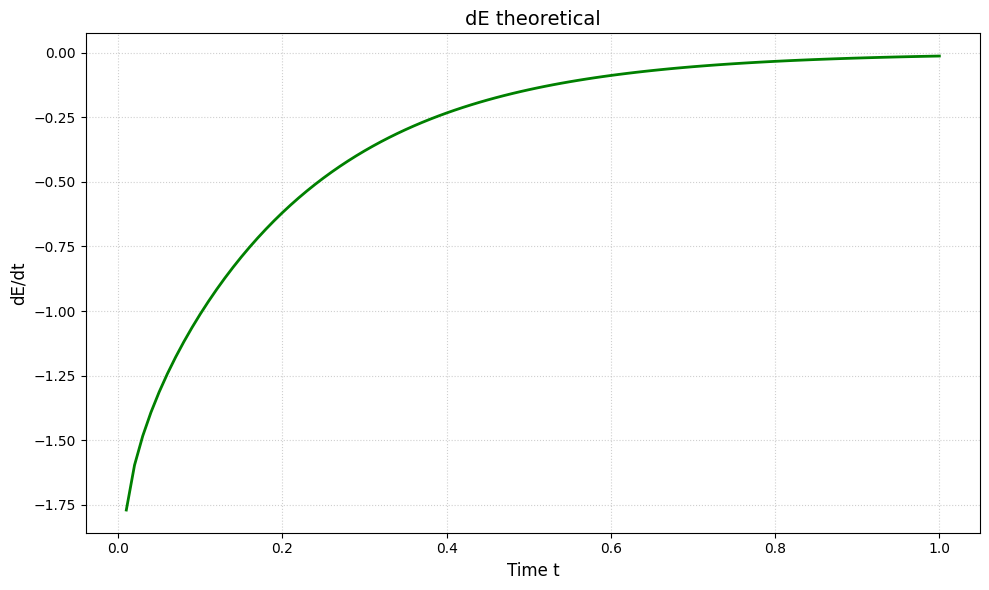

[np.float64(-1.7705802234919743), np.float64(-1.596928406510062), np.float64(-1.483882281181098), np.float64(-1.3924636253191347), np.float64(-1.3135452680258897)]


In [14]:
plt.figure(figsize=(10, 6))

plt.plot(t2, dE_theor,  color='green', linewidth=2)

plt.title('dE theoretical', fontsize=14)
plt.xlabel('Time t', fontsize=12)
plt.ylabel('dE/dt', fontsize=12)

# Grid: 'alpha' controls transparency, 'linestyle' makes it less distracting
plt.grid(True, linestyle=':', alpha=0.6)



# 4. Show/Save
plt.tight_layout() # Adjusts spacing so labels don't get cut off
plt.savefig('dE_theoretical.png')
plt.show()

print(dE_theor[:5])

In [15]:
dE_comp = Foll.dE_computed(hw,1/5)
print(dE_comp.shape)

(101,)


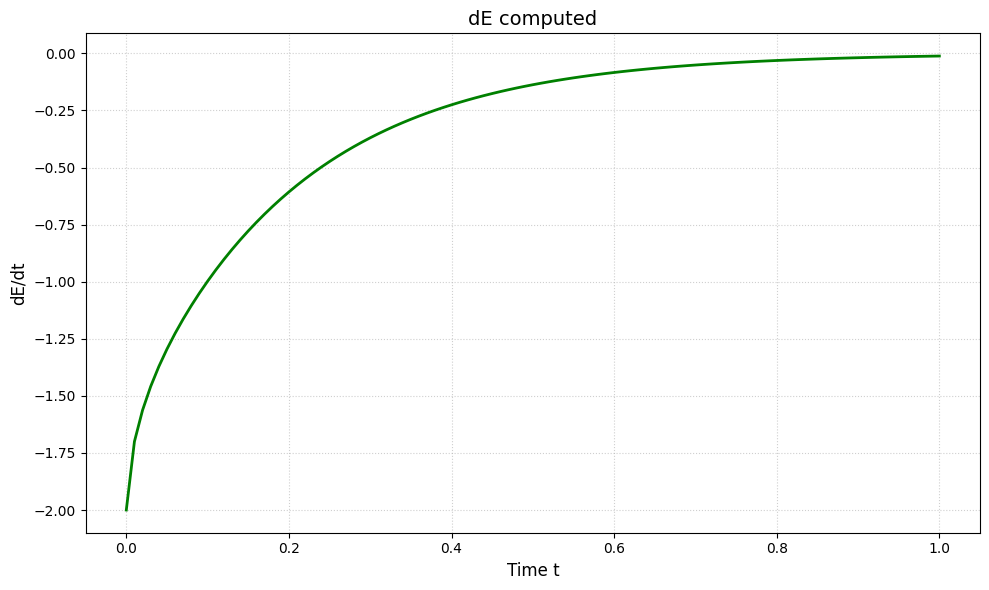

[-2.         -1.7        -1.5625     -1.45859375 -1.37158203]


In [16]:
plt.figure(figsize=(10, 6))

plt.plot(t, dE_comp, color='green', linewidth=2)

plt.title('dE computed', fontsize=14)
plt.xlabel('Time t', fontsize=12)
plt.ylabel('dE/dt', fontsize=12)

# Grid: 'alpha' controls transparency, 'linestyle' makes it less distracting
plt.grid(True, linestyle=':', alpha=0.6)



# 4. Show/Save
plt.tight_layout() # Adjusts spacing so labels don't get cut off
plt.savefig('dE_computed.png')
plt.show()

print(dE_comp[:5])

## Hliðruð Jaðarskilyrði

In [17]:
def psi2(t):
    return 1 + 1/2 *np.sin(2*np.pi*t)

def phi2(t):
    return 1 - 1/2 * np.cos(2*np.pi*t)

N2 = 20
M2 = 200

In [18]:
hw2 = Foll.heatwave(L_0, T_0, N2, M2, psi2, phi2, f_0)
t2 = np.linspace(0,1,201)

dE_comp2 = Foll.dE_computed(hw2,1/10)

Sigma: 0.4999999999999999


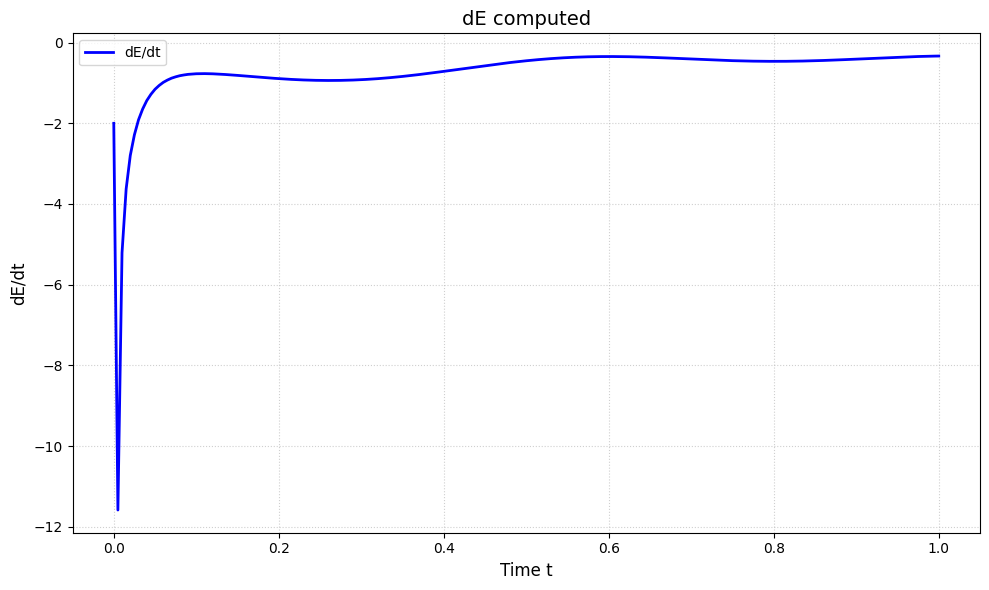

[ -2.         -11.58713779  -5.21028876  -3.62727265  -2.79786027]


In [19]:
plt.figure(figsize=(10, 6))

plt.plot(t2, dE_comp2, label='dE/dt', color='blue', linewidth=2)

plt.title('dE computed', fontsize=14)
plt.xlabel('Time t', fontsize=12)
plt.ylabel('dE/dt', fontsize=12)

# Grid: 'alpha' controls transparency, 'linestyle' makes it less distracting
plt.grid(True, linestyle=':', alpha=0.6)

# Legend: automatically uses the 'label' arguments from plt.plot()
plt.legend(loc='best', frameon=True)

# 4. Show/Save
plt.tight_layout() # Adjusts spacing so labels don't get cut off
plt.show()

print(dE_comp2[:5])

# Hluti 2

## Prufukeyrsla

In [20]:
L1 = 1
L2 = 1
h = 1/5
k = 1/4

def ub(x):
    return np.ones_like(x)

def ut(x):
    return np.ones_like(x)*2

def vl(y):
    return np.ones_like(y)*3

def vr(y):
    return np.ones_like(y)*4

def f(x, y):
    return x

In [21]:
print(Foll.PoissonEq(L1, L2, h, k, ub, ut, vl, vr, f))

[[1.         1.         1.         1.         1.         1.        ]
 [3.         2.23912343 2.02541792 2.15980541 2.69821089 4.        ]
 [3.         2.6107921  2.48194051 2.65083273 3.15363484 4.        ]
 [3.         2.56315406 2.44823837 2.58262586 3.02224151 4.        ]
 [2.         2.         2.         2.         2.         2.        ]]


## Bein Lausn

In [22]:
def ut2(x):
    return np.exp(-L2*x)

def vl2(y):
    return np.ones_like(y)

def vr2(y):
    return np.exp(-L2*y)

def f2(x,y):
    return -np.exp(-x*y)*(x**2+y**2)

h2 = 1/10
k2 = 1/15

In [23]:
ps = Foll.PoissonEq(L1,L2,h2,k2,ub,ut2,vl2,vr2,f2)

print(ps[-5:][-5:])

[[1.         0.92914595 0.86335532 0.80225318 0.74549704 0.6927731
  0.64379308 0.59829155 0.55602388 0.51676449 0.4803053 ]
 [1.         0.92298779 0.85194825 0.78640288 0.72591815 0.67009898
  0.61858383 0.5710412  0.52716678 0.48668135 0.44932896]
 [1.         0.91687959 0.84070602 0.77088169 0.70686947 0.64818201
  0.59437513 0.54504322 0.49981569 0.45835414 0.42035038]
 [1.         0.91082626 0.82963173 0.75568723 0.68834012 0.62699972
  0.57112962 0.52024215 0.47389386 0.43168172 0.39324072]
 [1.         0.90483742 0.81873075 0.74081822 0.67032005 0.60653066
  0.54881164 0.4965853  0.44932896 0.40656966 0.36787944]]


In [24]:
x = np.linspace(0,1,11)
y = np.linspace(0,1,16)

X, Y = np.meshgrid(x, y)

th = np.exp(-X * Y)
print(th[-5:][-5:])

[[1.         0.92929101 0.86358179 0.8025188  0.74577351 0.69304062
  0.64403642 0.59849726 0.55617813 0.51685133 0.4803053 ]
 [1.         0.92311635 0.85214379 0.78662786 0.72614904 0.67032005
  0.61878339 0.57120906 0.52729242 0.48675226 0.44932896]
 [1.         0.91698271 0.84085728 0.77105159 0.70704097 0.64834434
  0.59452055 0.54516506 0.49990693 0.45840601 0.42035038]
 [1.         0.91088982 0.82972026 0.75578374 0.68843572 0.62708909
  0.57120906 0.52030852 0.47394374 0.43171052 0.39324072]
 [1.         0.90483742 0.81873075 0.74081822 0.67032005 0.60653066
  0.54881164 0.4965853  0.44932896 0.40656966 0.36787944]]


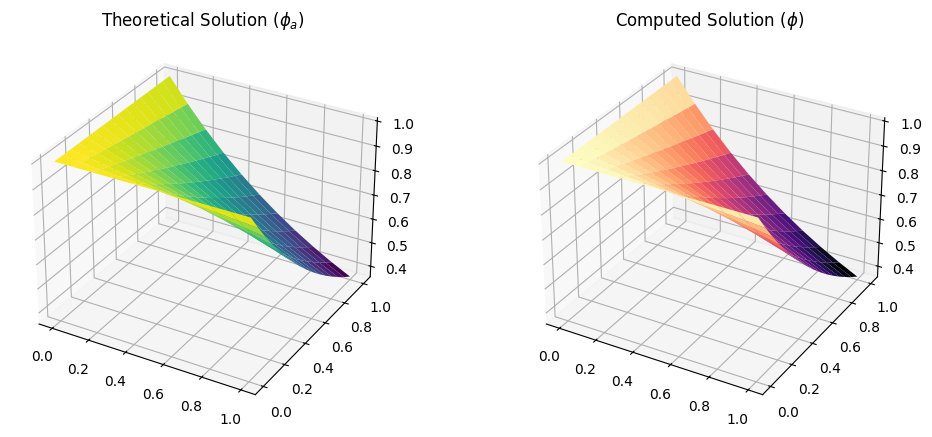

In [25]:
# 3. Plotting
fig = plt.figure(figsize=(12, 5))

# Theoretical Plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, Y, th, cmap='viridis')
ax1.set_title(r'Theoretical Solution ($\phi_a$)')

# Computed Plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X, Y, ps, cmap='magma')
ax2.set_title(r'Computed Solution ($\phi$)')

plt.show()

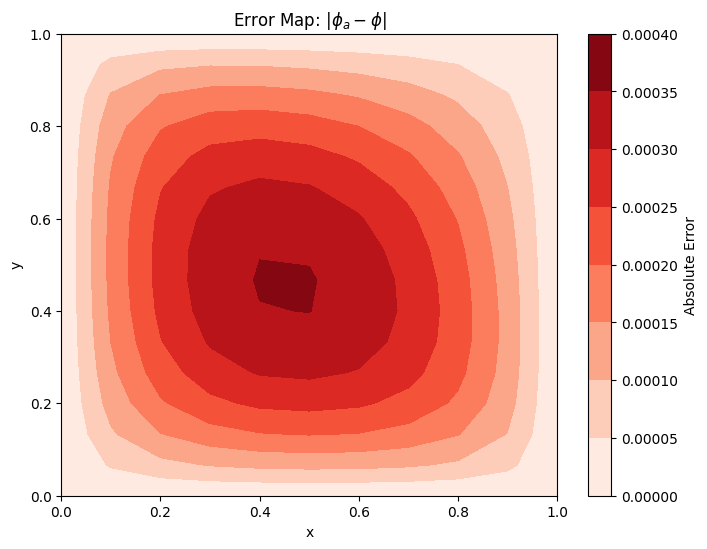

In [26]:
error = np.abs(th - ps)

plt.figure(figsize=(8, 6))
cp = plt.contourf(X, Y, error, cmap='Reds')
plt.colorbar(cp, label='Absolute Error')
plt.title(r'Error Map: $|\phi_a - \phi|$')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Lögmál Gauss

In [27]:
def ub3(x):
    return x*(1-x)

def ut3(x):
    return np.zeros_like(x)

def vl3(y):
    return y*(1-y)

def vr3(y):
    return np.zeros_like(y)

def f3(x,y):
    return x+y

Q = 1

In [28]:
hk = [1/5/i for i in range(1,9)]

Eg = []
for j in hk:
    phi = Foll.PoissonEq(L,L,j,j,ub3,ut3,vl3,vr3,f3)
    Flux = Foll.Flux(phi,L,L)
    Eg.append(np.abs(Q+Flux))

AttributeError: module 'matplotlib.pyplot' has no attribute 'invert_xaxis'

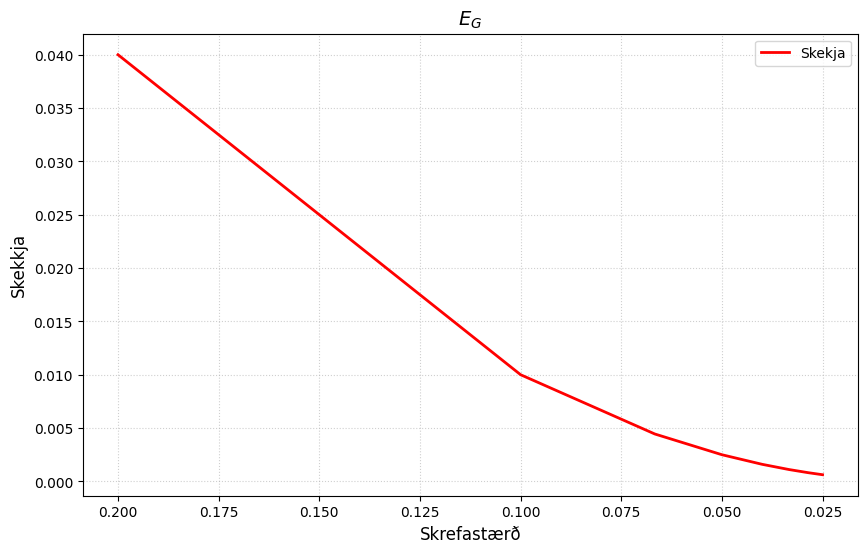

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(hk, Eg, label='Skekja', color='red', linewidth=2)

plt.title('$E_G$', fontsize=14)
plt.xlabel('Skrefastærð', fontsize=12)
plt.ylabel('Skekkja', fontsize=12)

# Grid: 'alpha' controls transparency, 'linestyle' makes it less distracting
plt.grid(True, linestyle=':', alpha=0.6)

# Legend: automatically uses the 'label' arguments from plt.plot()
plt.legend(loc='best', frameon=True)

plt.gca().invert_xaxis()
plt.invert_xaxis()

# 4. Show/Save
plt.tight_layout() # Adjusts spacing so labels don't get cut off
plt.show()